### Objective

The objective of this step is to analyze how different customer issue topics change over time. Using the topic labels assigned in the previous step, we examine which issues are increasing, persistent, or declining based on complaint trends.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/complaints_with_topics.csv")
print(df.shape)
df.head(3)

(50000, 9)


,Date received,Consumer complaint narrative,Product,Issue,Sub-issue,Company,clean_text,dominant_topic,year
0,2018-07-20,I live in the city of XXXX Maryland. The City ...,Mortgage,Trouble during payment process,NaN,PRIMARY RESIDENTIAL MORTGAGE,i live in the city of maryland. the city off...,0,2018
1,2017-06-23,My account balance on my capital one checking ...,Checking or savings account,Managing an account,Funds not handled or disbursed as instructed,CAPITAL ONE FINANCIAL CORPORATION,my account balance on my capital one checking ...,3,2017
2,2018-10-19,multiple attempts to collect on a debt that ha...,Debt collection,Attempts to collect debt not owed,Debt was already discharged in bankruptcy and ...,CAPITAL ONE FINANCIAL CORPORATION,multiple attempts to collect on a debt that ha...,0,2018


In [3]:
df.dtypes

Date received                   object
Consumer complaint narrative    object
Product                         object
Issue                           object
Sub-issue                       object
Company                         object
clean_text                      object
dominant_topic                   int64
year                             int64
dtype: object

In [4]:
df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")
df["year"] = df["Date received"].dt.year

In [5]:
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

In [6]:
topic_labels = {
    0: "Loan & Mortgage Repayment Issues",
    1: "Incorrect Late Payment Reporting",
    2: "Debt Collection & Validation Disputes",
    3: "Bank Account & Credit Card Issues",
    4: "Narrative / Unclear Complaints",
    5: "Identity Theft & Unverified Accounts",
    6: "Student Loan Servicing Issues",
    7: "Credit Reporting & Bureau Disputes"
}
df["topic_label"] = df["dominant_topic"].map(topic_labels)
df[["dominant_topic", "topic_label"]].head()

,dominant_topic,topic_label
0,0,Loan & Mortgage Repayment Issues
1,3,Bank Account & Credit Card Issues
2,0,Loan & Mortgage Repayment Issues
3,7,Credit Reporting & Bureau Disputes
4,7,Credit Reporting & Bureau Disputes


In [8]:
important_topics = [
    "Credit Reporting & Bureau Disputes",
    "Loan & Mortgage Repayment Issues",
    "Bank Account & Credit Card Issues",
    "Identity Theft & Unverified Accounts",
    "Student Loan Servicing Issues"
]

df_focus = df[df["topic_label"].isin(important_topics)]

In [9]:
topic_year_counts = (
    df_focus
    .groupby(["year", "topic_label"])
    .size()
    .reset_index(name="complaint_count")
)

In [ ]:
year_totals = (
    df.groupby("year")
    .size()
    .reset_index(name="total_complaints")
)

In [11]:
topic_year_counts = topic_year_counts.merge(
    year_totals,
    on="year",
    how="left"
)

topic_year_counts["proportion"] = (
    topic_year_counts["complaint_count"] /
    topic_year_counts["total_complaints"]
)

topic_year_counts.head()

,year,topic_label,complaint_count,total_complaints,proportion
0,2015,Bank Account & Credit Card Issues,1898,7325,0.259113
1,2015,Credit Reporting & Bureau Disputes,1583,7325,0.216109
2,2015,Identity Theft & Unverified Accounts,2,7325,0.000273
3,2015,Loan & Mortgage Repayment Issues,3261,7325,0.445188
4,2015,Student Loan Servicing Issues,575,7325,0.078498


In [12]:
trend_pivot = topic_year_counts.pivot(
    index="year",
    columns="topic_label",
    values="proportion"
).fillna(0)

trend_pivot

topic_label,Bank Account & Credit Card Issues,Credit Reporting & Bureau Disputes,Identity Theft & Unverified Accounts,Loan & Mortgage Repayment Issues,Student Loan Servicing Issues
year,,,,,
2015,0.259113,0.216109,0.000273,0.445188,0.078498
2016,0.270664,0.232247,0.002522,0.422487,0.067035
2017,0.234175,0.354345,0.003646,0.327169,0.073772
2018,0.254669,0.371636,0.004984,0.302452,0.054562
2019,0.239588,0.365428,0.004926,0.316614,0.060009


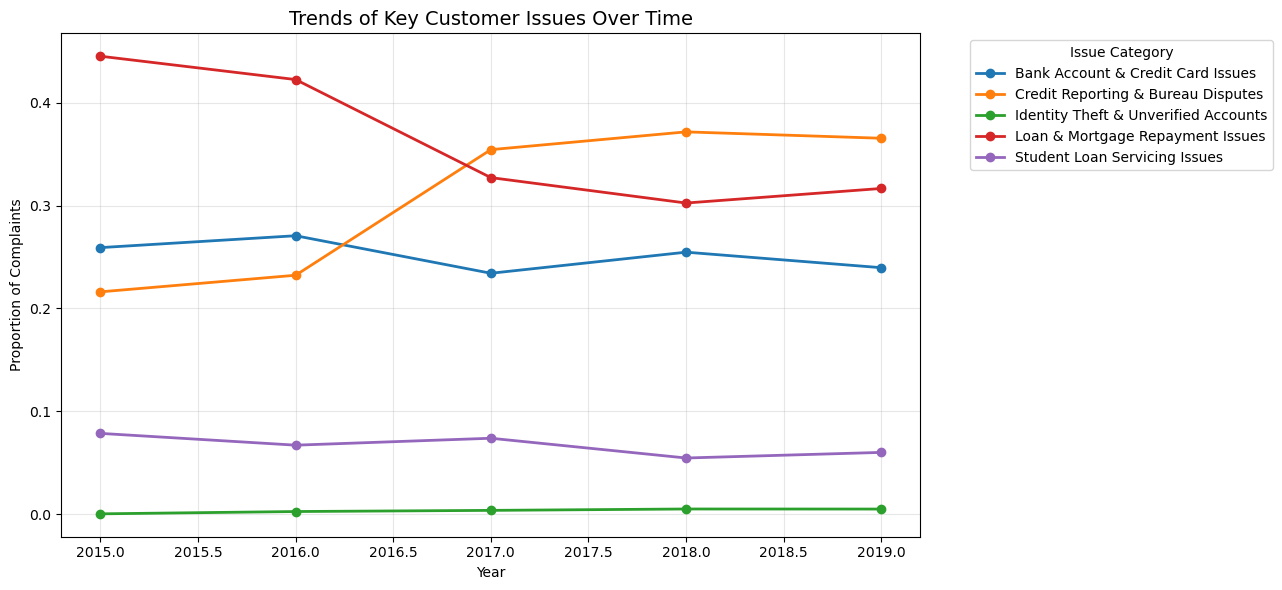

In [13]:
plt.figure(figsize=(13, 6))

for topic in trend_pivot.columns:
    plt.plot(
        trend_pivot.index,
        trend_pivot[topic],
        marker="o",
        linewidth=2,
        label=topic
    )

plt.title("Trends of Key Customer Issues Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Proportion of Complaints")
plt.legend(title="Issue Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

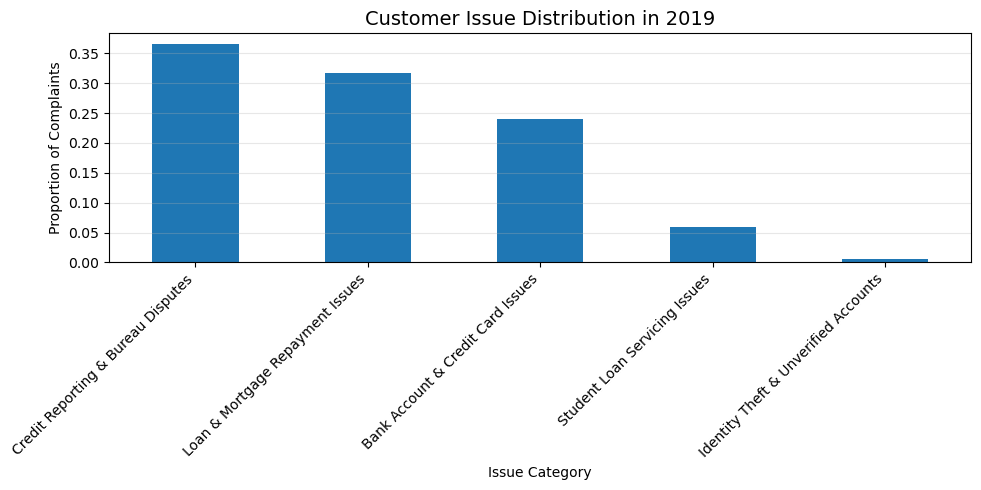

In [15]:
latest_year = trend_pivot.index.max()

latest_distribution = trend_pivot.loc[latest_year].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
latest_distribution.plot(kind="bar")

plt.title(f"Customer Issue Distribution in {latest_year}", fontsize=14)
plt.xlabel("Issue Category")
plt.ylabel("Proportion of Complaints")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Trend Interpretation

The trend analysis reveals clear differences in how customer issues evolve over time. Loan and mortgage repayment issues represent a large share of complaints throughout the period but show a gradual decline and stabilization, suggesting a mature and persistent issue category rather than a growing risk.

In contrast, credit reporting and bureau-related disputes show a strong and sustained increase, becoming the most dominant complaint category after 2017. This trend indicates rising customer concern around credit reporting accuracy, dispute resolution, and bureau handling, and represents a potential regulatory and reputational risk area.

Bank account and credit card issues remain consistently significant across all years, highlighting ongoing operational challenges in everyday financial products. Student loan servicing issues and identity theft complaints appear at lower volumes but remain steady over time, suggesting niche yet sensitive problem areas that warrant continued monitoring.

Overall, the analysis demonstrates how combining topic modeling with time-based aggregation can surface both emerging risks and long-standing customer pain points from unstructured complaint data.

### Summary

- Loaded topic-labeled complaint data and prepared time-based features.
- Selected key topics based on impact and trend behavior rather than raw frequency.
- Analyzed how major customer issues change over time using proportional trends.
- Identified rising, persistent, and declining complaint categories.
- Translated topic modeling results into meaningful customer and product insights.
